Explained Variance Ratio:
[0.42889283 0.1614646  0.14375352 0.11119781 0.09539611 0.05929512]

Variance retained by first 2 components:
0.5903574298329866


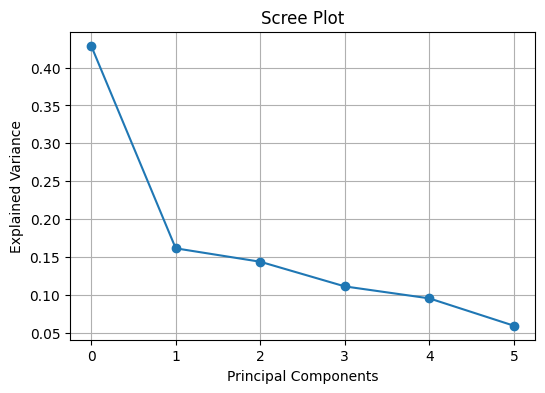

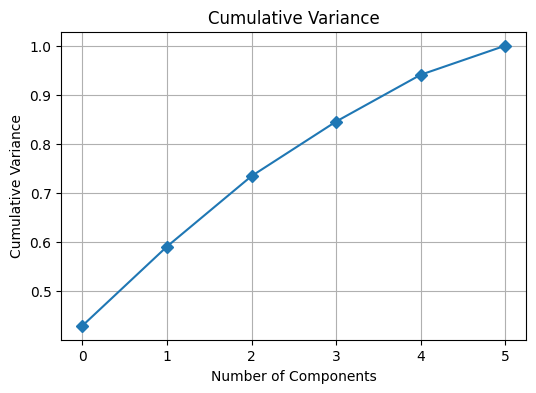

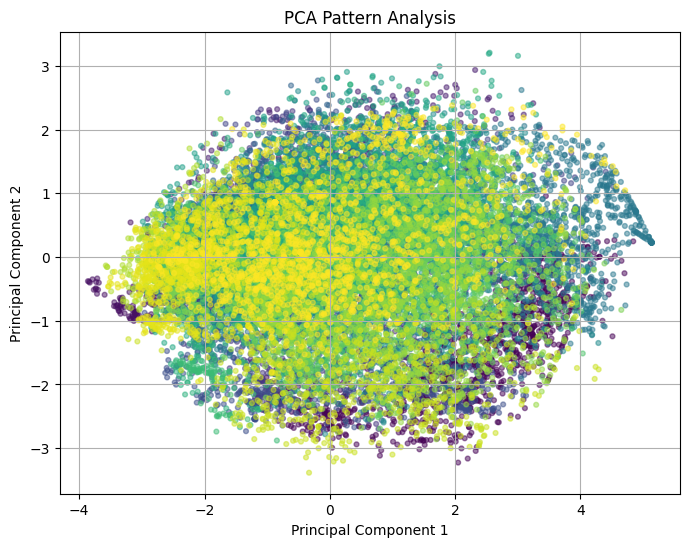


Feature Contribution:
            PC1       PC2
PM2.5  0.491536 -0.032443
PM10   0.468516  0.126074
NO2    0.456230  0.145185
SO2    0.362011 -0.240969
CO     0.338641 -0.657004
O3     0.291562  0.687207


In [9]:
#from google.colab import files
#uploaded = files.upload()
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("final_preprocessed_city_day.csv")
X = df[['PM2.5','PM10','NO2','SO2','CO','O3']]

# PCA (full)
pca = PCA()
X_pca = pca.fit_transform(X)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nVariance retained by first 2 components:")
print(sum(pca.explained_variance_ratio_[0:2]))

# Scree plot
plt.figure(figsize=(6,4))
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.grid()
plt.show()

# Cumulative variance
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.plot(cum_var, marker='D')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("Cumulative Variance")
plt.grid()
plt.show()

# PCA with 2 components
pca2 = PCA(n_components=2)
X_final = pca2.fit_transform(X)

pca_df = pd.DataFrame(X_final, columns=['PC1','PC2'])
# Add City for coloring
pca_df['City'] = df['City']

# SCATTER PLOT (City colors)

plt.figure(figsize=(8,6))

city_codes = pca_df['City'].astype('category').cat.codes

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=city_codes,
    alpha=0.5,
    s=12
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Pattern Analysis")
plt.grid()

plt.show()
# Feature Contribution
loadings = pd.DataFrame(
    pca2.components_.T,
    columns=['PC1','PC2'],
    index=['PM2.5','PM10','NO2','SO2','CO','O3']
)

print("\nFeature Contribution:")
print(loadings)